## XGBM and LGBM

The provided Titanic_test.csv file was not used for model training and evaluation because it does not contain the target variable (Survived). Since evaluation metrics such as Accuracy, Precision, Recall, and F1-score require the actual class labels, the test dataset could not be used for performance evaluation.

Therefore, only Titanic_train.csv was used. After preprocessing, the dataset was split into training and testing sets using train_test_split(). This allowed the models to be trained on one portion of the data and evaluated on the remaining portion using the required performance metrics.

In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

In [153]:
df = pd.read_csv("Titanic_train.csv")

In [154]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [155]:
df.shape

(891, 12)

In [156]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [158]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [159]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Visualizations

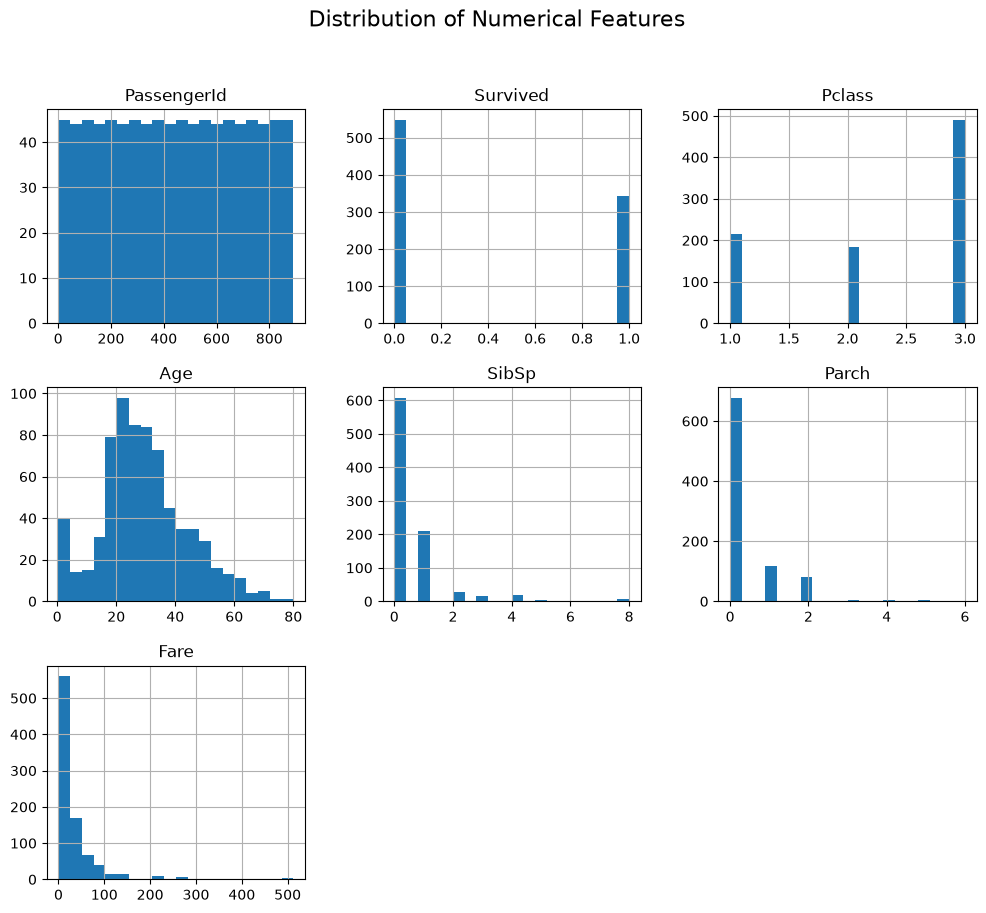

In [160]:
#Histogram
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

* The Age distribution shows that most passengers were between 20 and 40 years old.
* More passengers did not survive than survived, as the count for Survived = 0 is higher than Survived = 1.
* Most passengers traveled in third class, followed by first class and second class.
* Most passengers were traveling alone or with only one sibling/spouse, while very few traveled with larger families.
* Most passengers had no parents or children accompanying them, and only a small number traveled with larger families.
* The Fare distribution is highly right-skewed, with most passengers paying lower fares and only a few paying very high fares.
* PassengerId is almost uniformly distributed since it is simply a unique identifier assigned to each passenger.


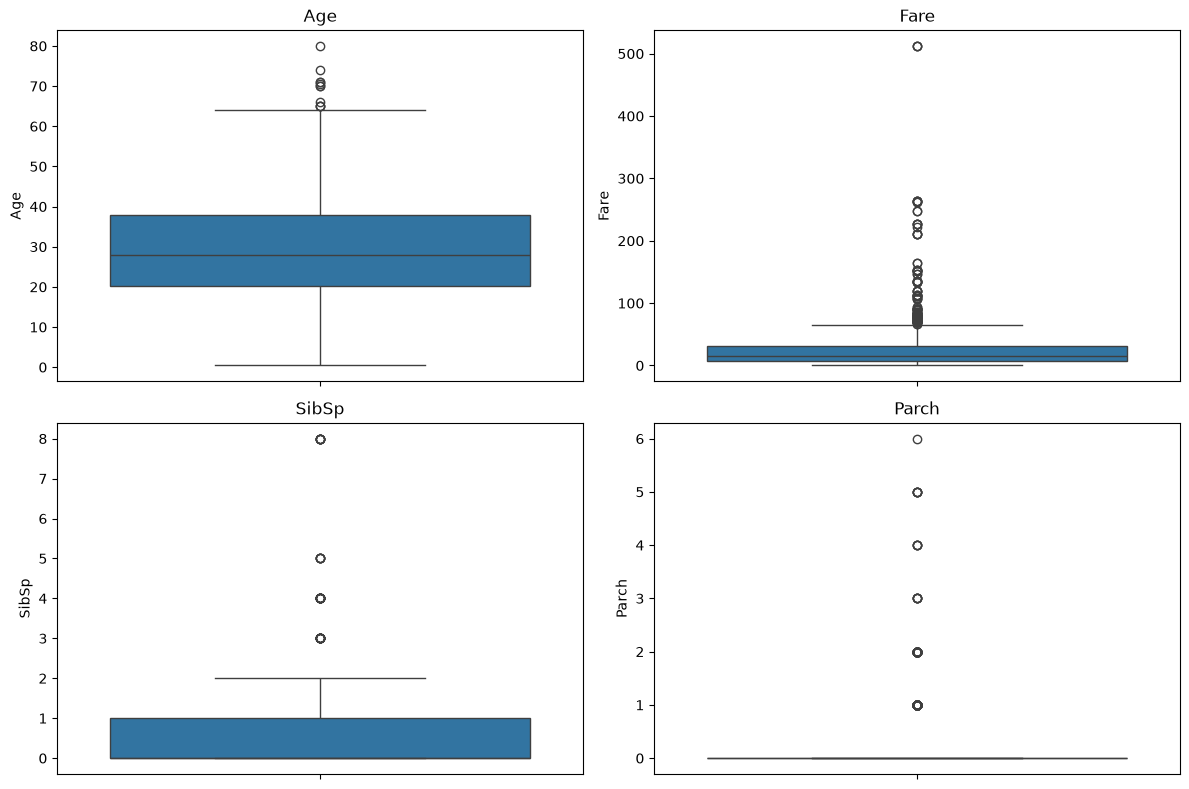

In [161]:
#Boxplot
numerical_columns = ["Age", "Fare", "SibSp", "Parch"]
plt.figure(figsize=(12,8))
for i, column in enumerate(numerical_columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

* The Age column has a few outliers, but most passengers were between 20 and 40 years of age.
* The Fare column contains many outliers, indicating that a few passengers paid much higher fares than the majority.
* Most passengers had 0 or 1 sibling/spouse (SibSp), with only a few passengers having larger family sizes.
* Most passengers had no parents or children (Parch) accompanying them, while only a few passengers had higher values.
* Among all the numerical features, the Fare column has the highest number of outliers.

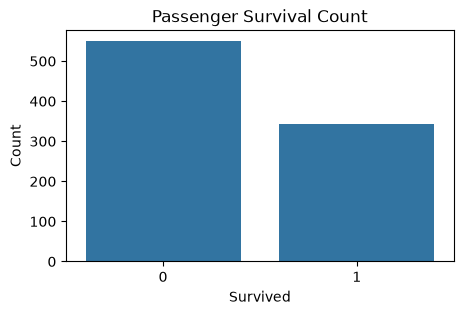

In [162]:
#Survival 
plt.figure(figsize=(5,3))
sns.countplot(x="Survived", data=df)
plt.title("Passenger Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

Most passengers did not survive.

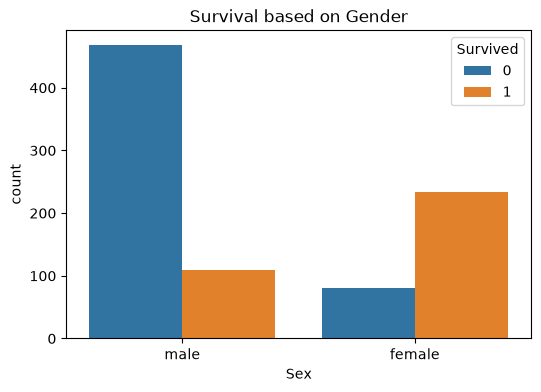

In [163]:
#Survival by Gender
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival based on Gender")
plt.show()

Female passengers had a much higher survival rate compared to male passengers.

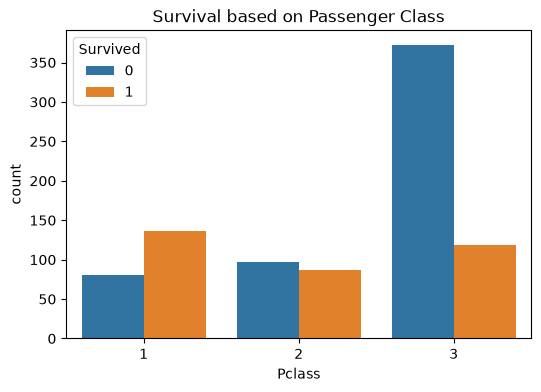

In [164]:
#Survival by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival based on Passenger Class")
plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest.

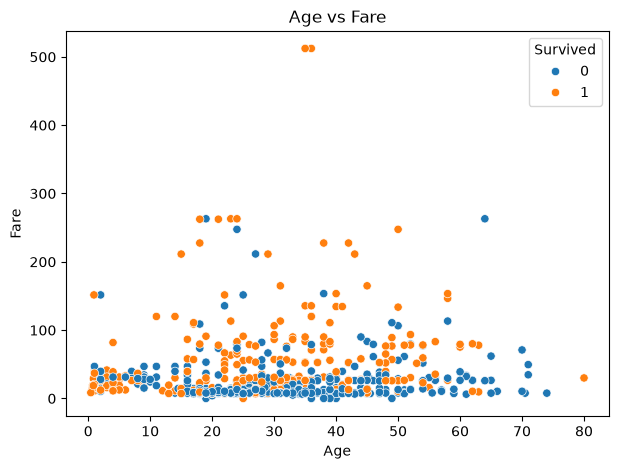

In [165]:
#Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.title("Age vs Fare")
plt.show()

Passengers who paid higher fares generally had better survival chances, although there is overlap between the two groups.

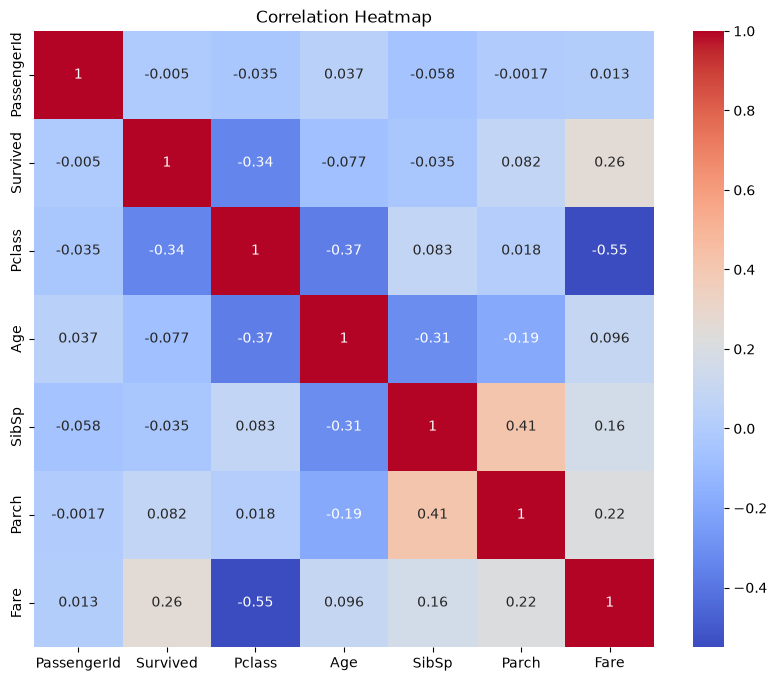

In [166]:
#Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

* Passenger class has a moderate negative correlation with survival (-0.34), indicating that passengers in higher classes were more likely to survive.
* Fare has a positive correlation with survival (0.26), suggesting that passengers who paid higher fares had better chances of survival.
* Passenger class and fare have the strongest negative correlation (-0.55), showing that higher-class passengers generally paid higher fares.
* SibSp and Parch have a moderate positive correlation (0.41), indicating that passengers traveling with siblings or spouses were often traveling with parents or children.
* Age has a very weak negative correlation with survival (-0.08), suggesting that age alone had little impact on survival.
* Most other features have weak correlations with each other, indicating that there are no strong linear relationships among them.

### EDA

In [167]:
data = df.copy()
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [168]:
#Cabin has a large number of missing values, so it is dropped
data.drop(columns=["Cabin"], inplace=True)
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [169]:
#Filling missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Fare"] = data["Fare"].fillna(data["Fare"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

In [170]:
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [171]:
#Removing unimportant columns
data.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [172]:
# Encoding categorical columns
label_encoder = LabelEncoder()
data["Sex"] = label_encoder.fit_transform(data["Sex"])
data["Embarked"] = label_encoder.fit_transform(data["Embarked"])

In [173]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [174]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

In [175]:
X.shape

(891, 7)

In [176]:
y.shape

(891,)

In [177]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

### XGBM

In [178]:
xgb_model = XGBClassifier(random_state=42,eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

In [198]:
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)

In [199]:
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

Accuracy : 0.8100558659217877
Precision: 0.7536231884057971
Recall   : 0.7536231884057971
F1 Score : 0.7536231884057971


In [201]:
#Confusion Matrix
cm = confusion_matrix(y_test, xgb_predictions)
print(cm)

[[93 17]
 [17 52]]


In [181]:
print(classification_report(y_test, xgb_predictions))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [182]:
#5-Fold Cross Validation
xgb_cv = cross_val_score(xgb_model,X,y,cv=5,scoring="accuracy")

print("Cross Validation Scores")
print(xgb_cv)
print("\nAverage Accuracy :", xgb_cv.mean())

Cross Validation Scores
[0.79329609 0.82022472 0.84831461 0.78089888 0.84831461]

Average Accuracy : 0.8182097796748478


#### Hyperparameter Tuning

In [ ]:
parameters = {"n_estimators": [50, 100],"max_depth": [3, 5],"learning_rate": [0.05, 0.1]}
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"),
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)
grid_xgb.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls t

In [184]:
print("Best Parameters")
print(grid_xgb.best_params_)
print("\nBest Accuracy")
print(grid_xgb.best_score_)

Best Parameters
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

Best Accuracy
0.8259233724022457


## LGBM

In [185]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [202]:
lgbm_predictions = lgbm_model.predict(X_test)

In [187]:
lgbm_accuracy = accuracy_score(y_test, lgbm_predictions)
lgbm_precision = precision_score(y_test, lgbm_predictions)
lgbm_recall = recall_score(y_test, lgbm_predictions)
lgbm_f1 = f1_score(y_test, lgbm_predictions)

In [188]:
print("Accuracy :", lgbm_accuracy)
print("Precision:", lgbm_precision)
print("Recall   :", lgbm_recall)
print("F1 Score :", lgbm_f1)

Accuracy : 0.7988826815642458
Precision: 0.7619047619047619
Recall   : 0.6956521739130435
F1 Score : 0.7272727272727273


In [203]:
#Confusion Matrix
cm = confusion_matrix(y_test, lgbm_predictions)
print(cm)

[[95 15]
 [21 48]]


In [190]:
#Classification Report
print(classification_report(y_test, lgbm_predictions))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.76      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [191]:
#5-Fold Cross Validation
lgbm_cv = cross_val_score(lgbm_model,X,y,cv=5,scoring="accuracy")
print("Cross Validation Scores")
print(lgbm_cv)
print("\nAverage Accuracy :", lgbm_cv.mean())

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 202
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

### Hyperparameter Tuning

In [ ]:
parameters = {"n_estimators": [50, 100],"learning_rate": [0.05, 0.1],"num_leaves": [31, 50]}
grid_lgbm = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=parameters,
    cv=5,
    scoring="accuracy"
)
grid_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 218, number of negative: 351
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 184
[LightGBM] [Info] Number of data points in the train set: 569, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383128 -> initscore=-0.476291
[LightGBM] [Info] Start training from score -0.476291
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'n_estimators': [50, 100], 'num_leaves': [31, 50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls 

In [193]:
print("Best Parameters")
print(grid_lgbm.best_params_)
print("\nBest Accuracy")
print(grid_lgbm.best_score_)

Best Parameters
{'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31}

Best Accuracy
0.8273121244952231


In [204]:
# Creating a comparison table
Metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ],
    "LightGBM": [
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1
    ]
})

In [205]:
Metrics

,Metric,XGBoost,LightGBM
0,Accuracy,0.810056,0.798883
1,Precision,0.753623,0.761905
2,Recall,0.753623,0.695652
3,F1-Score,0.753623,0.727273


## Comparison

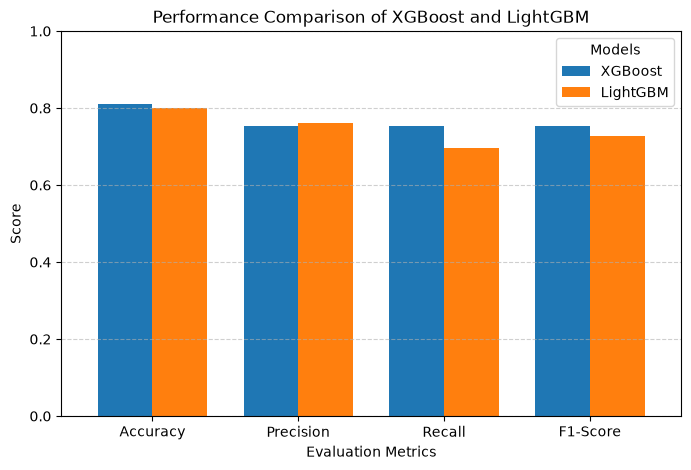

In [209]:
Metrics.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5),
    width=0.75
)
plt.title("Performance Comparison of XGBoost and LightGBM")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Models")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

* Both XGBoost and LightGBM achieved similar performance across all evaluation metrics, indicating that both models are effective for the Titanic classification problem.
* XGBoost achieved slightly higher Accuracy, Recall, and F1-Score, suggesting that it classified passengers more accurately and identified surviving passengers more effectively.
* LightGBM achieved slightly higher Precision, indicating that when it predicted a passenger would survive, it was marginally more likely to be correct.
* The higher Recall and F1-Score of XGBoost indicate a better balance between correctly identifying survivors and minimizing misclassifications.


### Strengths and Weaknesses

**XGBoost**
* Strengths:
  * Higher Accuracy, Recall, and F1-Score.
  * Better overall classification performance.
  * Good balance between Precision and Recall.
* Weaknesses:
  * Slightly lower Precision than LightGBM.
  * May require more training time than LightGBM



**LightGBM**
* Strengths:
  * Slightly higher Precision.
  * Faster training and lower memory usage on large datasets.
* Weaknesses:
  * Lower Recall and F1-Score compared to XGBoost.
  * Slightly lower overall classification accuracy.